# **===========================================================================================================================================================** #
# **Incremental Capstone 7 - Credit Card Agency Clustering** #
# **===========================================================================================================================================================** #

### **Imports** ###

In [125]:
#Import Statments
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score

from sklearn.linear_model import (
    LinearRegression,
    Ridge, 
    Lasso,
    ElasticNet
)

### **Utility Functions** ###

In [126]:

data_set_name = ''
target_label = ''

def DisplayTable(df_target, table_title=None, max_cell_length=30):

    if df_target.empty:
        print(f"No data to display{': ' + table_title if table_title else ''}")
        return

    n_rows, n_cols = df_target.shape

    fig_height = (n_rows + 1) * 0.35
    if table_title:
        fig_height += 0.4
    
    fig, ax = plt.subplots(figsize=(n_cols * 1.5, fig_height))
    ax.axis('off')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    # Format floats and truncate long text
    cell_text = []
    for row in df_target.values:
        new_row = []
        for val in row:
            if isinstance(val, (float, int)) and not isinstance(val, bool):
                new_row.append(f"{val:.2f}")
            else:
                s = str(val)
                if len(s) > max_cell_length:
                    s = s[:max_cell_length - 3] + '...'
                new_row.append(s)
        cell_text.append(new_row)

    table = ax.table(
        cellText=cell_text,
        colLabels=df_target.columns,
        cellLoc='center',
        loc='upper center',
        bbox=[0, 0, 1, 1]
    )

    # Bold column headers and set header background
    for col in range(n_cols):
        table[(0, col)].set_facecolor('#4a90d9')
        table[(0, col)].set_text_props(color='white', fontweight='bold')

    # Light blue background for data cells
    for row in range(1, n_rows + 1):
        for col in range(n_cols):
            table[(row, col)].set_facecolor('#d4e6f1')

    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.auto_set_column_width(col=list(range(n_cols)))

    if table_title is not None:
        fig.suptitle(table_title, fontweight='bold', fontsize=14)

    plt.tight_layout(rect=[0, 0, 1, 0.95] if table_title else [0, 0, 1, 1])

    plt.show()
    plt.close(fig)
    
def PrintDataFrameStatistics(df_target):
    # Print Stats
    print("***********************************")
    print("Description Stats")
    print("***********************************")
    print()

    # Capture for Table plot
    df_stats = df_target.describe(include='all').T.reset_index()
    df_stats.rename(columns={'index': 'Feature'}, inplace=True)
    print(df_stats)
    print()

    # Print df Column Info
    print("***********************************")
    print("Basic Info of imported data set")
    print("***********************************")
    print()

    df_info = pd.DataFrame({
                            'Feature': df_target.columns,
                            'Non-Null Count': df_target.notna().sum().values,
                            'Null Count': df_target.isna().sum().values,
                            'Dtype': df_target.dtypes.values
                            }).reset_index(drop=True)

    print(f'Dataset Shape:{df_target.shape}')
    df_shape = pd.DataFrame({'Rows': [df_target.shape[0]], 'Columns': [df_target.shape[1]]})
    print()

    print('Do we have any features with null values?:')
    print(df_target.isnull().any().any())
    print()

    print('Feature Columns with that have null values:')
    print(df_target.isnull().sum()[df_target.isnull().sum() > 0])

    # Capture for Table plot
    cols_to_plot = df_target.select_dtypes(exclude=['number']).columns
    missing = df_target[cols_to_plot].isnull().sum()
    missing = missing[missing > 0]
    df_missing = pd.DataFrame({
                                'Feature': missing.index,
                                'Missing Count': missing.values,
                                'Missing %': (missing.values / len(df_target) * 100).round(2)
                                }).reset_index(drop=True)
    print()

    print('Do we have any features with nan values?:')

    cols_to_plot = df_target.select_dtypes(include=['number']).columns
    nan_vals = df_target[cols_to_plot].isna().sum()
    nan_vals = nan_vals[nan_vals > 0]
    # Capture for Table plot
    df_nan = pd.DataFrame({
                            'Feature': nan_vals.index,
                            'NaN Count': nan_vals.values,
                            'NaN %': (nan_vals.values / len(df_target) * 100).round(2)
                        }).reset_index(drop=True)
    print(df_target.isna().any().any())

    # Sum up the number of missing features per row
    missing_per_row = df_target.isna().sum(axis=1)  # count missing per row
    missing_counts = missing_per_row.value_counts().sort_index()  # count rows for each missing count

    df_missingfeature_rowcounts = pd.DataFrame({
        'Missing Features': missing_counts.index,
        'Row Count': missing_counts.values
    })

    print("***********************************")
    print("First 20 rows of Data")
    print("***********************************")
    print()
    print(df_target.head(20))
    print()

    print("***********************************")
    print("First 20 rows of Random Sample Data")
    print("***********************************")
    print()
    df_randomsample = df_target.sample(n=20)
    print(df_target.sample(20))
    print()

    #
    # Display Results in Pretty Tables
    #
    print('Display Analysis Results in Tables')
    DisplayTable(df_stats, f'{data_set_name} Description Statistics')
    print()
    DisplayTable(df_info, f'{data_set_name} Basic Information')
    print()
    DisplayTable(df_shape, f'{data_set_name} Dataset Shape')
    print()
    DisplayTable(df_missing, f'{data_set_name} Missing Categorical (String) Data')
    print()
    DisplayTable(df_nan, f'{data_set_name} Missing Numeric Data')
    print()
    DisplayTable(df_missingfeature_rowcounts, f'{data_set_name} Summary of Missing Feature Row Counts')
    print()    
    DisplayTable(df_randomsample, f'{data_set_name} Random Data Sample')
    print()

### **Initial Data Load** ###

In [127]:
# Loading Credit Card Data
df_CreditCardAgency_Original = pd.read_csv('CC_GENERAL.csv')

# Make a copy of the dataframe to contain the modifications completed in this workbook
df_CreditCardAgency = df_CreditCardAgency_Original.copy(deep=True)


data_set_name = 'Credit Card Data'
target_label = ''

### **Initial Exploratory Data Analysis** ###

***********************************
Description Stats
***********************************

                             Feature   count unique     top freq         mean  \
0                            CUST_ID    8950   8950  C10001    1          NaN   
1                            BALANCE  8950.0    NaN     NaN  NaN  1564.474828   
2                  BALANCE_FREQUENCY  8950.0    NaN     NaN  NaN     0.877271   
3                          PURCHASES  8950.0    NaN     NaN  NaN  1003.204834   
4                   ONEOFF_PURCHASES  8950.0    NaN     NaN  NaN   592.437371   
5             INSTALLMENTS_PURCHASES  8950.0    NaN     NaN  NaN   411.067645   
6                       CASH_ADVANCE  8950.0    NaN     NaN  NaN   978.871112   
7                PURCHASES_FREQUENCY  8950.0    NaN     NaN  NaN     0.490351   
8         ONEOFF_PURCHASES_FREQUENCY  8950.0    NaN     NaN  NaN     0.202458   
9   PURCHASES_INSTALLMENTS_FREQUENCY  8950.0    NaN     NaN  NaN     0.364437   
10            CASH

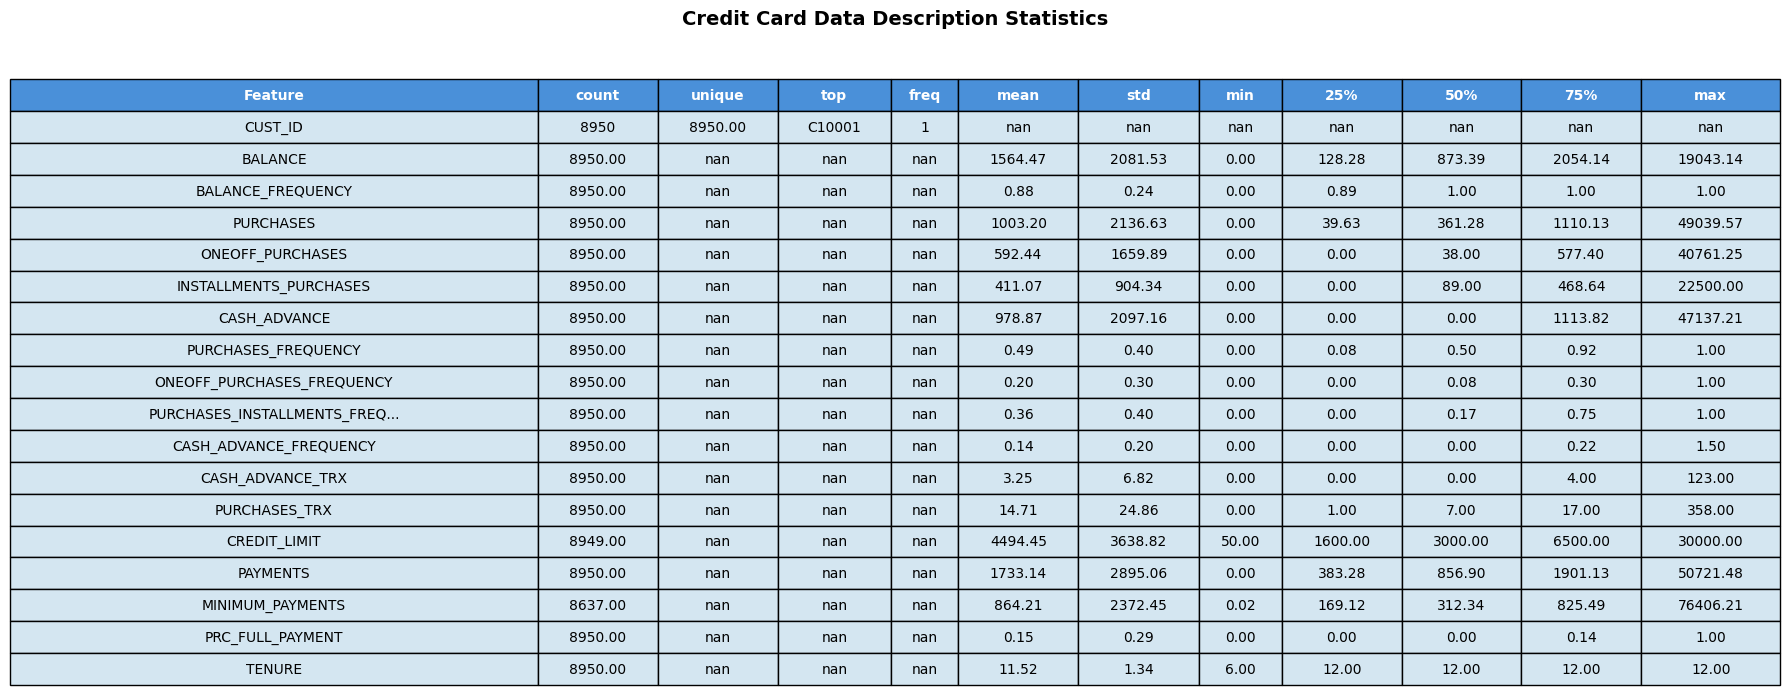

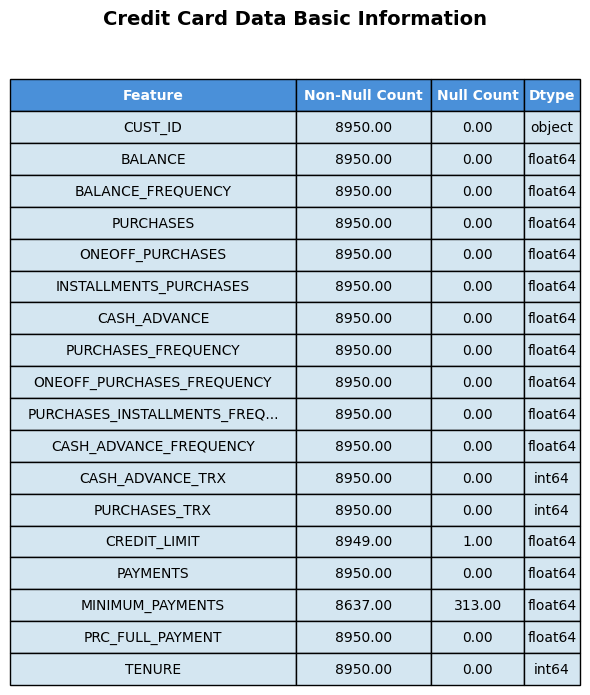

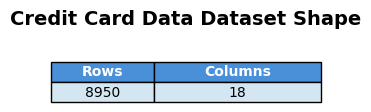


No data to display: Credit Card Data Missing Categorical (String) Data



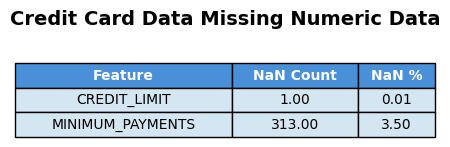

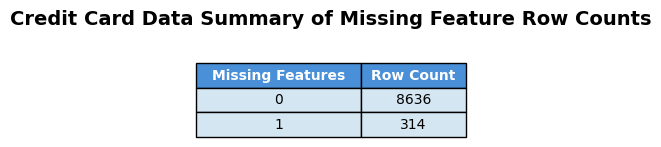

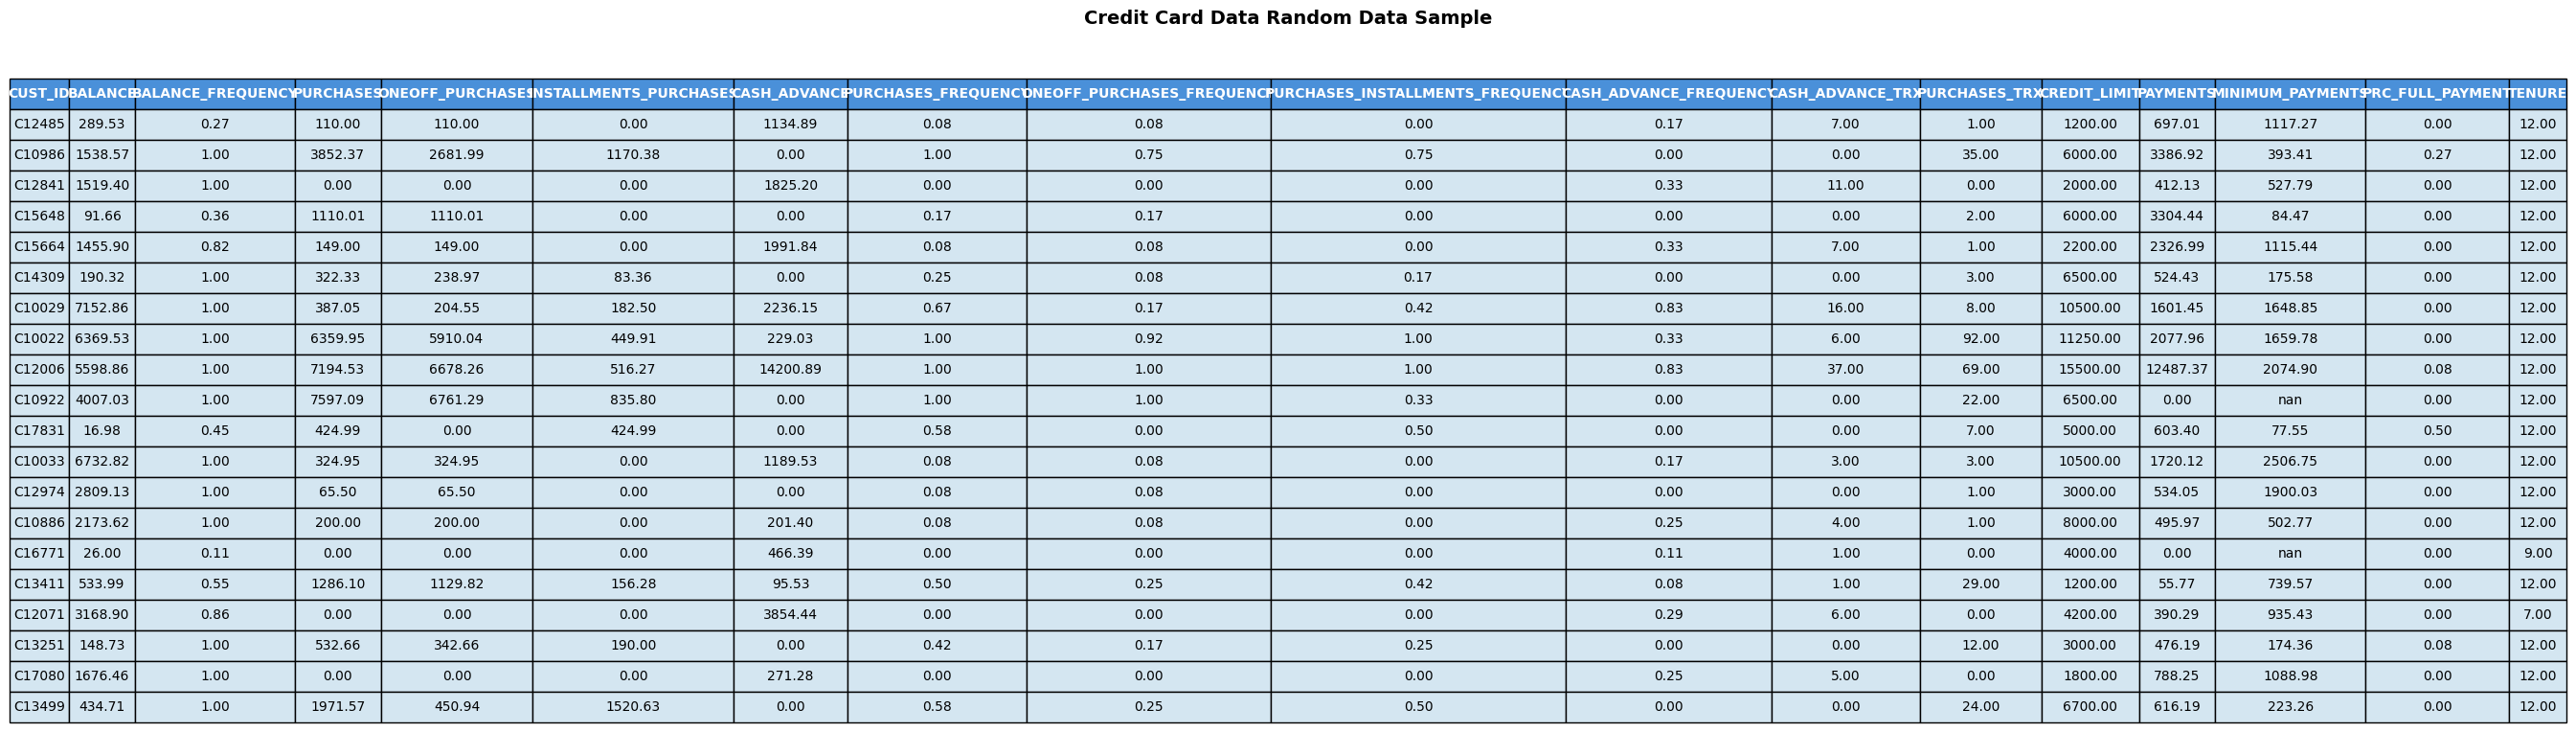

In [128]:
# print out the dataframe stats
PrintDataFrameStatistics(df_CreditCardAgency)

### **Initial EDA Analysis** ###
    - We have 8950 rows of data
    - The dataset has 18 columns of data:
        - 1 categorical feature
        - 17 numeric features
    - We have 314 rows containing missing values
        - MINIMUM_PAYMENTS  - 313 missing values
        - CREDIT_LIMIT      - 1 missing value
    - Missing values need to be imputed.
    - Need to investigate whether missing value columns have actual meaning within datarow/relationship
    - For performance considerations, we should change numeric types where appropriate (int, float32)

### **Missing Values and Imputation** ###

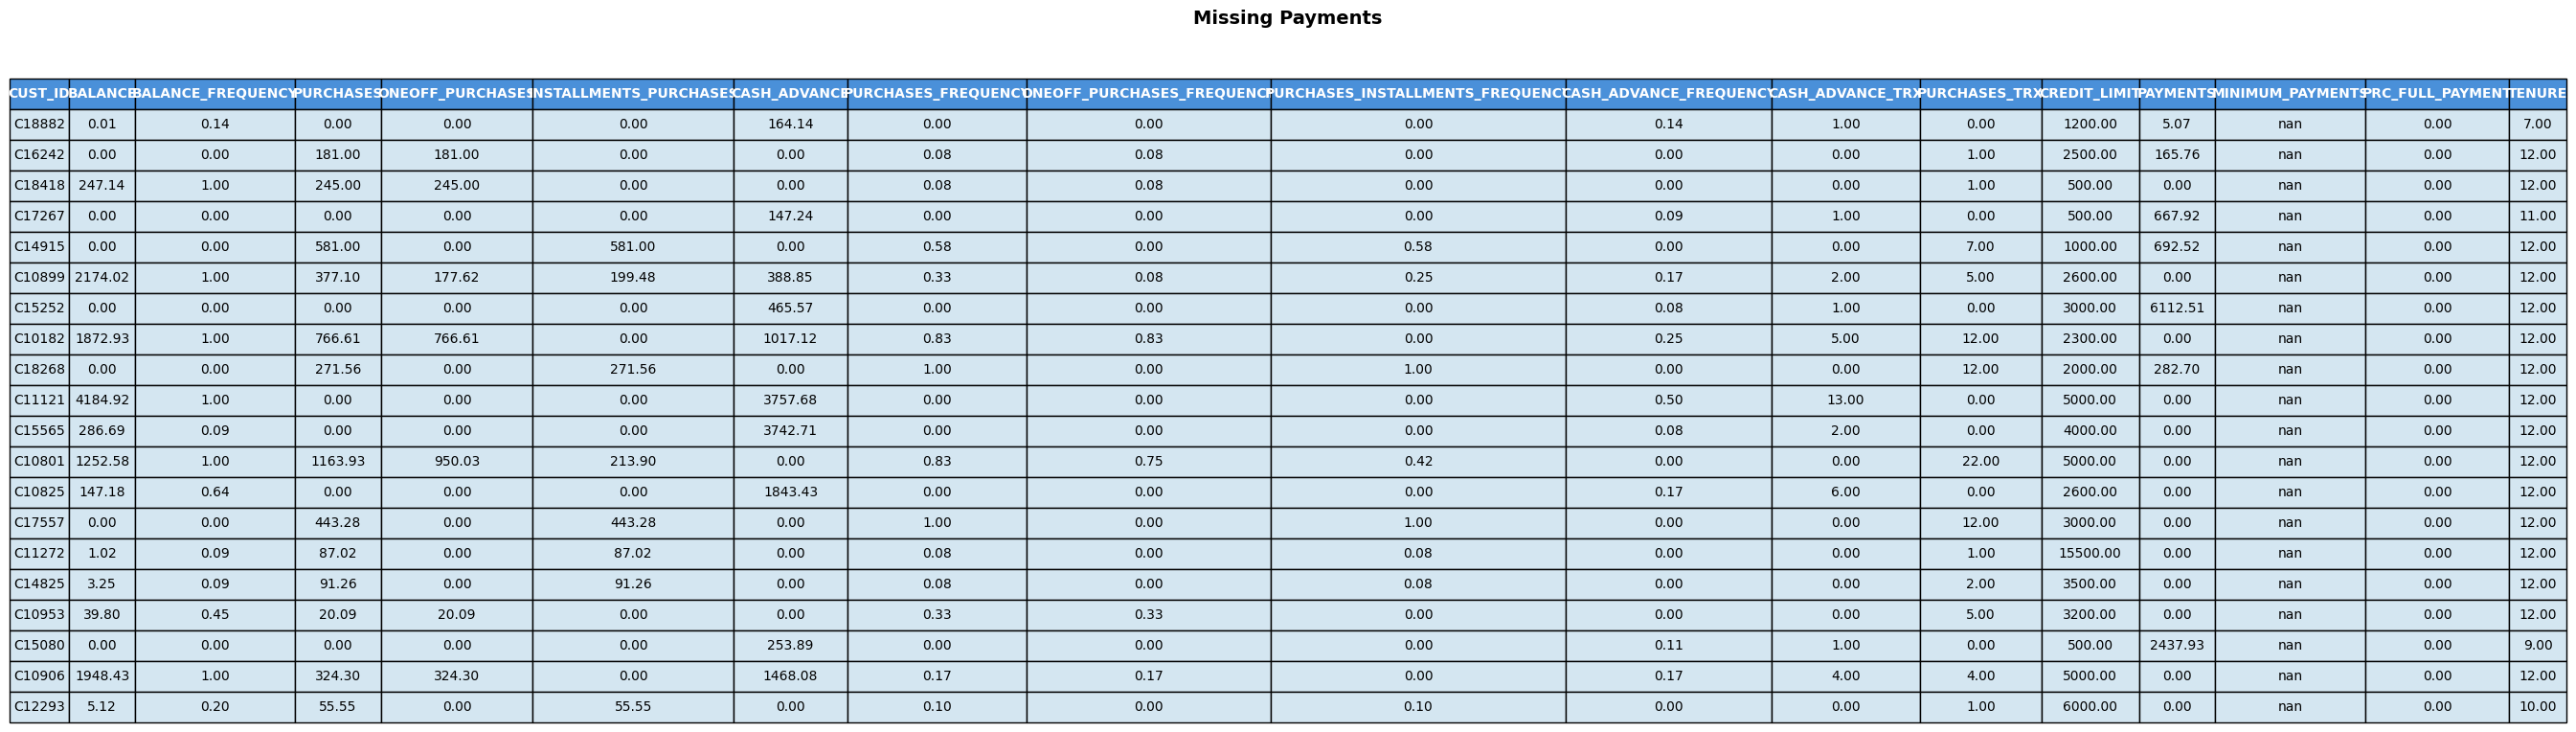

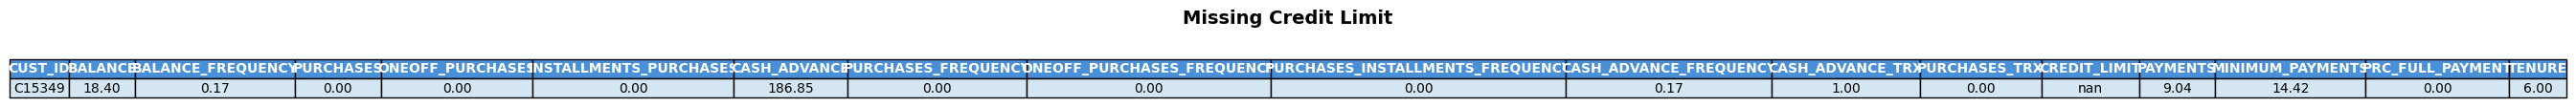

In [129]:
# Examine 
df_MissingPayments = df_CreditCardAgency[df_CreditCardAgency['MINIMUM_PAYMENTS'].isna()]
DisplayTable(df_MissingPayments.sample(n=20), 'Missing Payments')

df_CreditLimit = df_CreditCardAgency[df_CreditCardAgency['CREDIT_LIMIT'].isna()]
DisplayTable(df_CreditLimit, 'Missing Credit Limit')


##### **Missing Values Analysis** #####
    - PAYMENTS = 0 => MISSING_PAYMENT = 0
      Makes sense to imput with zero (0)
    - CREDIT_LIMIT 
      Makes sense to just take median (since there is only 1 instance)

In [130]:
# Imputation

# MINIMUM_PAYMENTS
df_CreditCardAgency['MINIMUM_PAYMENTS'] = df_CreditCardAgency['MINIMUM_PAYMENTS'].fillna(0)

# CREDIT_LIMIT
df_CreditCardAgency['CREDIT_LIMIT'] = df_CreditCardAgency['CREDIT_LIMIT'].fillna(df_CreditCardAgency['CREDIT_LIMIT'].median())

# Examine 
df_MissingPayments = df_CreditCardAgency[df_CreditCardAgency['MINIMUM_PAYMENTS'].isna()]
print(f'Missing MISSING_PAYMENTs Count:{len(df_MissingPayments)}')

df_CreditLimit = df_CreditCardAgency[df_CreditCardAgency['CREDIT_LIMIT'].isna()]
print(f'Missing CREDIT_LIMITs Count:{len(df_CreditLimit)}')

Missing MISSING_PAYMENTs Count:0
Missing CREDIT_LIMITs Count:0


### **Data Type Conversion** ###

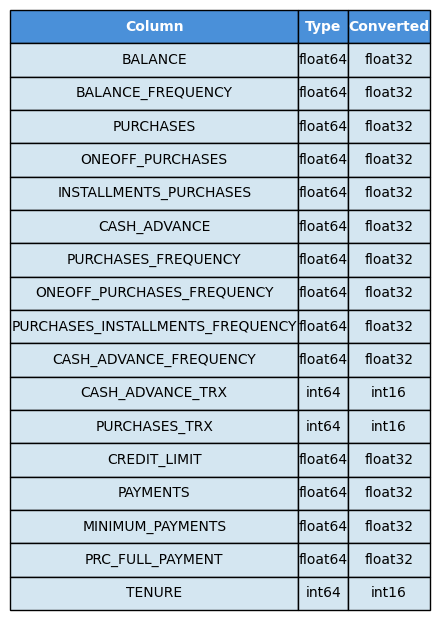

Converted Data Columns


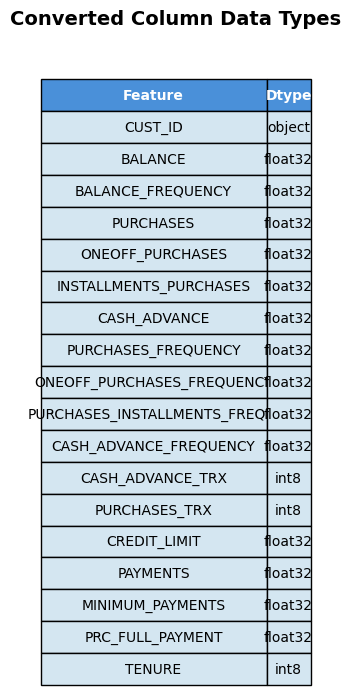

In [131]:
# Type Conversion
df_types = pd.DataFrame({
                            'Column': [
                                'BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES',
                                'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY',
                                'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY',
                                'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX',
                                'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE'
                            ],
                            'Type': [
                                'float64', 'float64', 'float64', 'float64', 'float64', 'float64',
                                'float64', 'float64', 'float64', 'float64', 'int64', 'int64',
                                'float64', 'float64', 'float64', 'float64', 'int64'
                            ],
                            'Converted': [
                                'float32', 'float32', 'float32', 'float32', 'float32', 'float32',
                                'float32', 'float32', 'float32', 'float32', 'int16', 'int16',
                                'float32', 'float32', 'float32', 'float32', 'int16'
                            ]
                        })

DisplayTable(df_types, max_cell_length=60)

# Convert Floats
float_columns = ['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES',
                 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY',
                 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY',
                 'CASH_ADVANCE_FREQUENCY', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS',
                 'PRC_FULL_PAYMENT']
df_CreditCardAgency[float_columns] = df_CreditCardAgency[float_columns].astype('float32')


# Convert Ints
int_columns = ['CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'TENURE']
df_CreditCardAgency[int_columns] = df_CreditCardAgency[int_columns].astype('int8')

print('Converted Data Columns')

df_info = pd.DataFrame({
                        'Feature': df_CreditCardAgency.columns,
                        'Dtype': df_CreditCardAgency.dtypes.values
                        }).reset_index(drop=True)
DisplayTable(df_info, 'Converted Column Data Types')

##### **Examining Normalized Values** #####
    - It looks like the following columns are normalized Values (0.0 - 1.0)
        BALANCE_FREQUENCY
        PURCHASES_FREQUENCY
        ONEOFF_PURCHASES_FREQUENCY
        PURCHASES_INSTALLMENTS_FREQUENCY
        CASH_ADVANCE_FREQUENCY
        PRC_FULL_PAYMENT

    - A quick eyeball examination shows that CASH_ADVANCE_FREQUENCY looks like it has 1 or more values > 1.0 (outlier/anamoly)

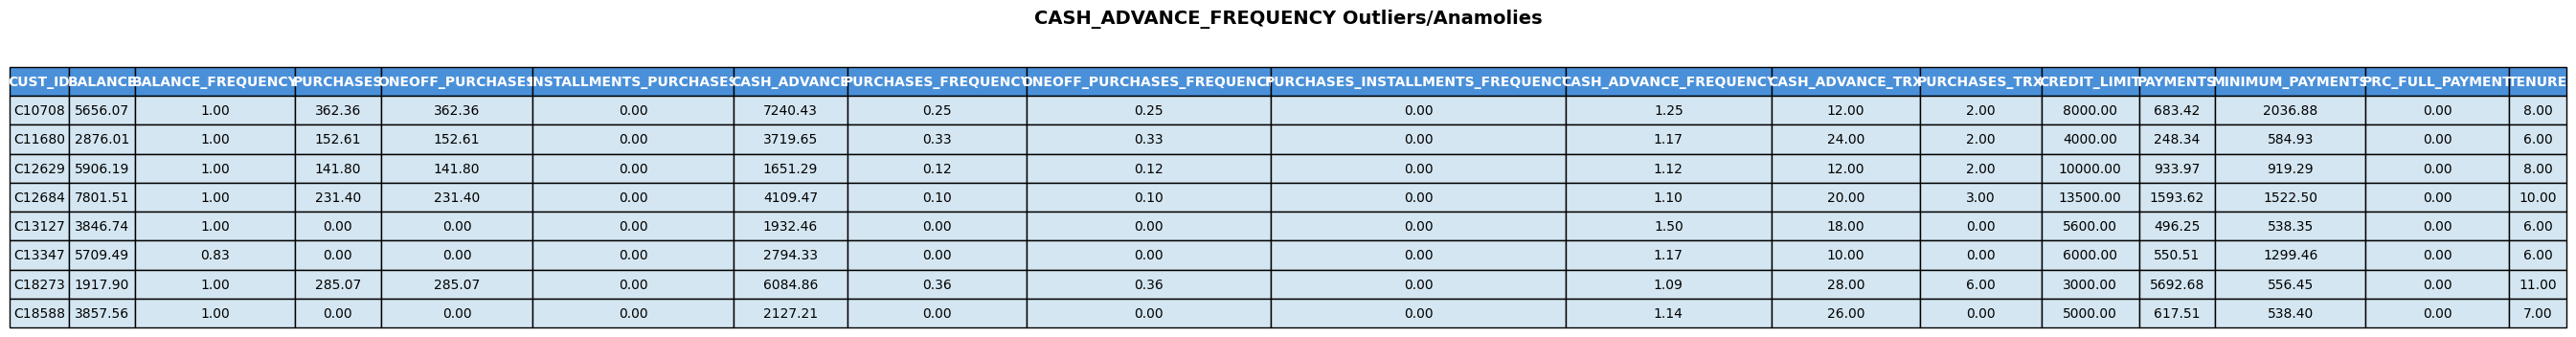

In [132]:
# How many outliers/anamolies do we have for CASH_ADVANCE_FREQUENCY

df_cashadvancefrequency_outliers = df_CreditCardAgency[df_CreditCardAgency_Original['CASH_ADVANCE_FREQUENCY'] > 1]
DisplayTable(df_cashadvancefrequency_outliers, 'CASH_ADVANCE_FREQUENCY Outliers/Anamolies')

#### **Plot Histograms of Numeric Data Columns** ####

C:\Users\jxbma\AppData\Local\Temp\ipykernel_76092\1388467066.py:36: RuntimeWarning: overflow encountered in scalar subtract
  range_val = data.max() - data.min()


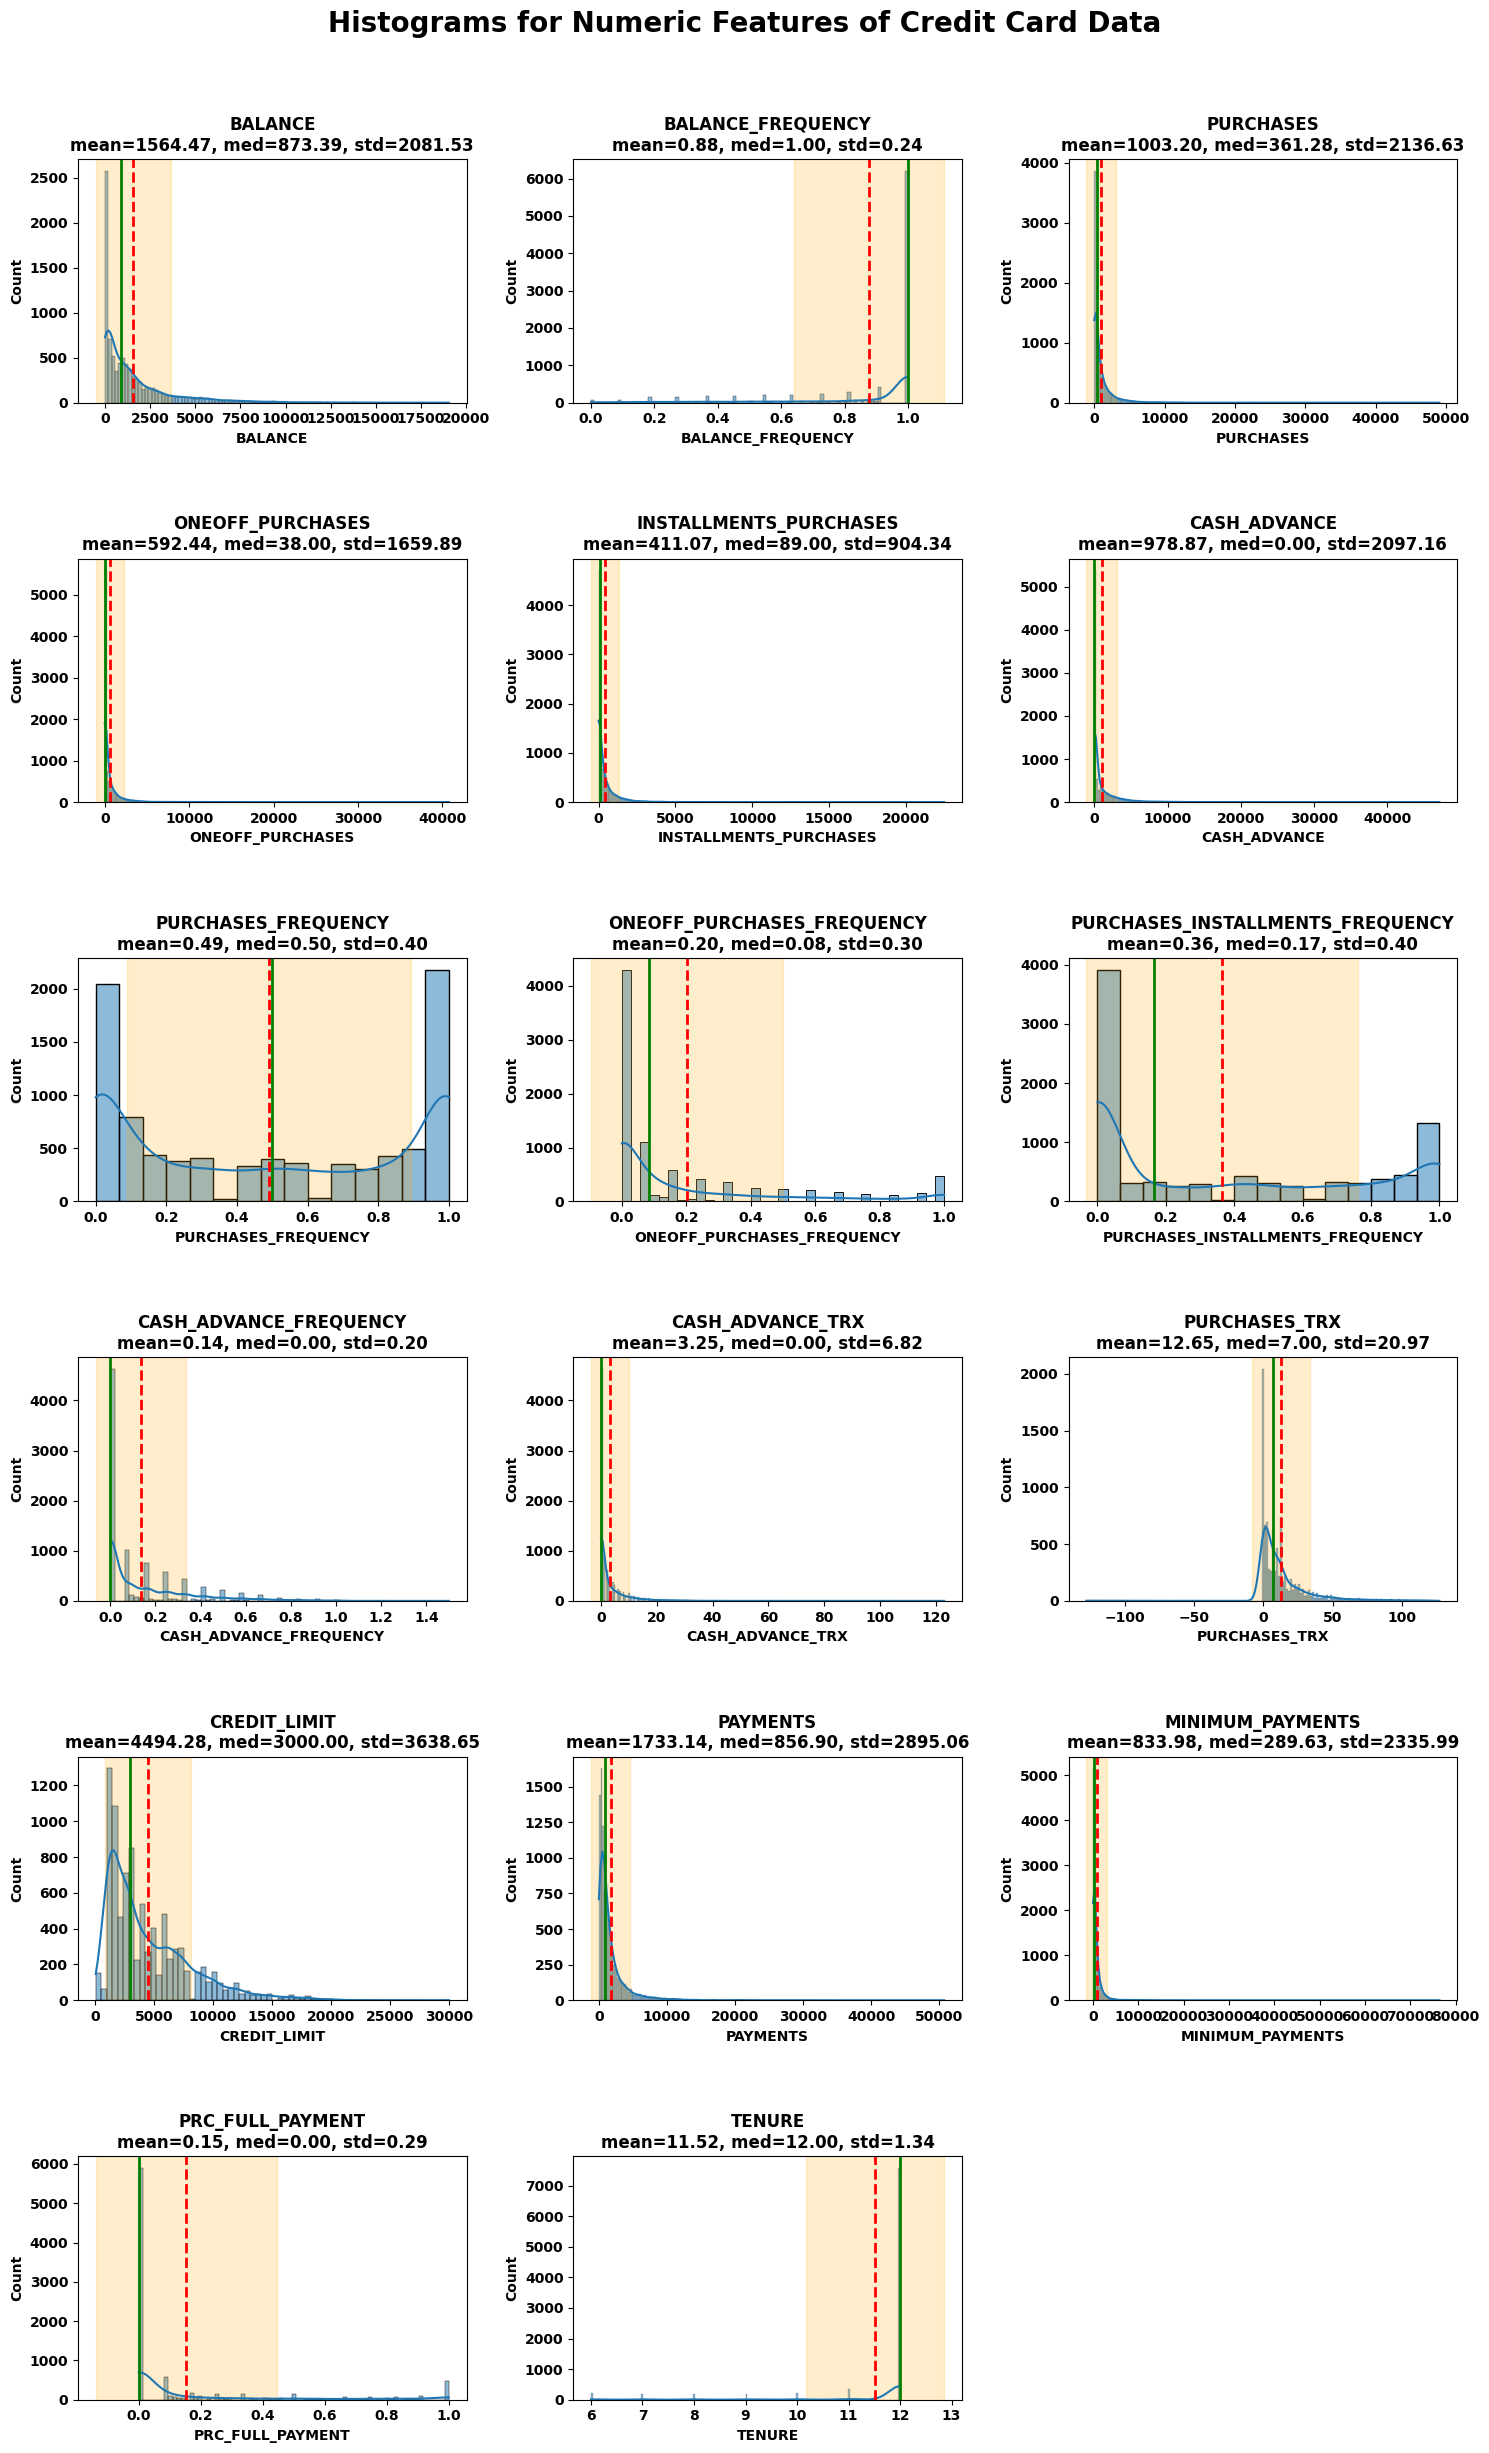

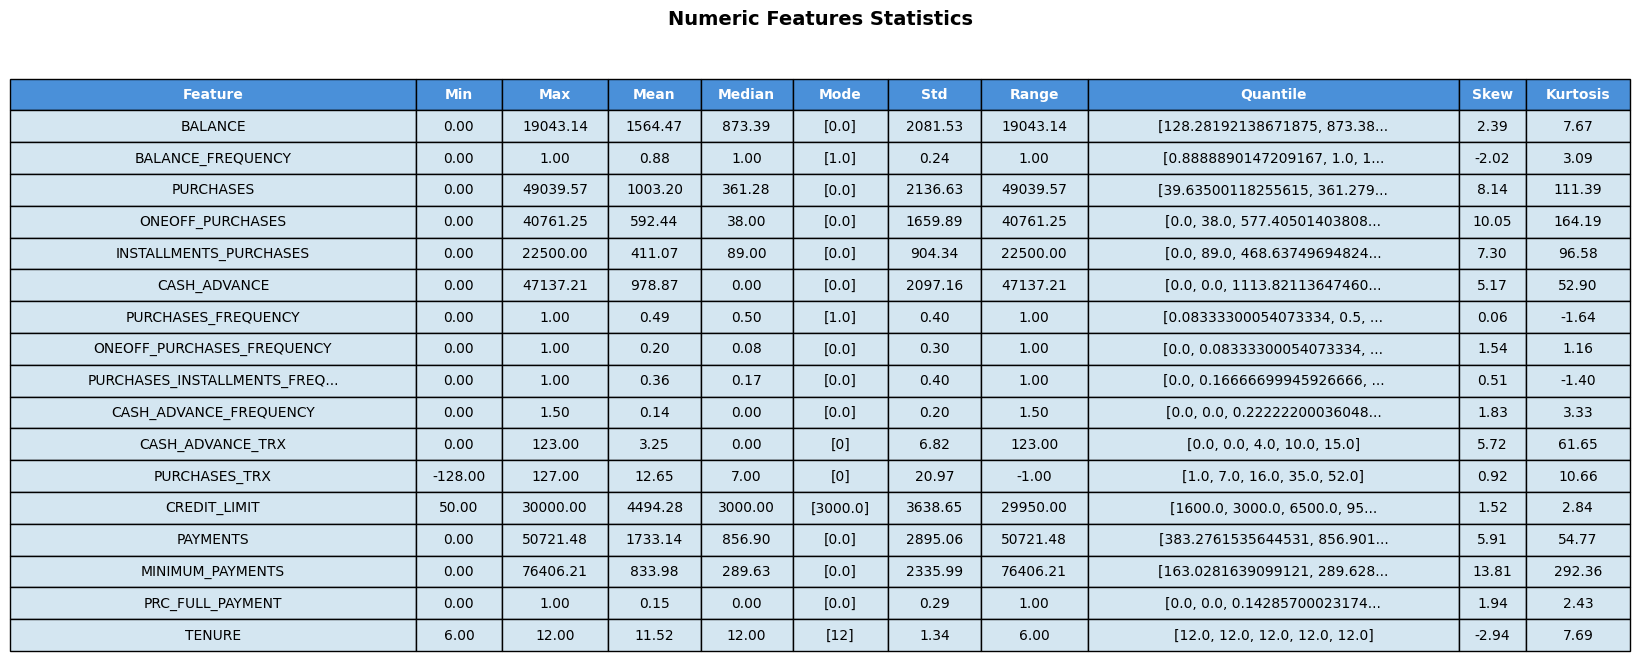

In [ ]:
def DisplayNumericFeatureHistograms(df_target, feature_columns = None, target_label=None, plot_title=None, display_statistics=True):

    cols_to_plot = []
    statistics = []
    
    if feature_columns is None:
        cols_to_plot = df_target.select_dtypes(include=['number']).columns
    else:
        cols_to_plot = feature_columns

    if target_label is not None:
        cols_to_plot = cols_to_plot.drop(target_label).tolist()
    
    number_of_cols = len(cols_to_plot)

    ncols = min(number_of_cols, 3)  # max 3 per row, but no more than n
    nrows = (number_of_cols + ncols - 1) // ncols

    # I need a 3 column plot
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
    axes = axes.flatten()

    # Iterate over each numeric column and plot a historbram
    for i, col in enumerate(cols_to_plot):

        sns.histplot(data=df_target, x=col, ax=axes[i], kde=True)

        axes[i].set_xlabel(col, fontweight='bold')
        axes[i].set_ylabel('Count', fontweight='bold')
        data = df_target[col]

        if display_statistics == True:

            min_val = data.min()
            max_val = data.max()
            range_val = data.max() - data.min()
            mean_val = data.mean()
            median_val = data.median()
            mode_val = data.mode().tolist()
            std_val = data.std()
            quantile_val = data.quantile([0.25, 0.5, 0.75, 0.90, 0.95]).tolist()
            skew_val = data.skew()
            kurtosis_val = data.kurtosis()

            stats = {
                'Feature': col,
                'Min': min_val,
                'Max': max_val,
                'Mean': mean_val,
                'Median': median_val,
                'Mode': mode_val,
                'Std': std_val,
                'Range': range_val,
                'Quantile': quantile_val,
                'Skew': skew_val,
                'Kurtosis': kurtosis_val
            }            

            statistics.append(stats)

            # print(f'Min Value: {min_val:.3f}')
            # print(f'Max Value: {max_val:.3f}')
            # print(f'Mean Value: {mean_val:.3f}')
            # print(f'Median Value: {median_val:.3f}')
            # print(f'Mode Value: {mode_val}')
            # print(f'Standard Deviation: {std_val:.3f}')
            # print(f'Range Value = {range_val:.3f}')
            # print(f'Quantile Value = {quantile_val}')
            # print(f'Skew Value: {skew_val:.3f}')
            # print(f'Kurtosis Value: {kurtosis_val:.3f}')            

            axes[i].set_title(f'{col}\nmean={mean_val:.2f}, med={median_val:.2f}, std={data.std():.2f}', fontweight='bold')

            # Vertical lines for mean and median, shaded std
            axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
            axes[i].axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.2f}')            
            axes[i].axvspan(mean_val - std_val, mean_val + std_val, alpha=0.2, color='orange', label=f'±1 Std')

        else:
            axes[i].set_title(f'{col}', fontweight='bold')
        
        # Tick labels in bold
        axes[i].tick_params(axis='both', labelsize=10)
        for label in axes[i].get_xticklabels() + axes[i].get_yticklabels():
            label.set_fontweight('bold')

    # Hide the blank/empty graphs
    for i in range(number_of_cols, len(axes)):
        fig.delaxes(axes[i])

    # Make plots more readable and add space
    title = None
    if plot_title is not None:
        title = plot_title
    else:
        title = f'Histograms for Numeric Features of {data_set_name}'

    plt.suptitle(f'Histograms for Numeric Features of {data_set_name}', y=1.02, fontsize=20, fontweight='bold')
    plt.subplots_adjust(top=0.92)  

    plt.tight_layout(h_pad=5)
    plt.show()  

    print()
    print()

    if display_statistics == True:
        df_statistics = pd.DataFrame(statistics)
        DisplayTable(df_statistics, 'Numeric Features Statistics')

def PlotBoxPlotsToViewDistributions(df_target, feature_columns = None, target_label=None, plot_title=None):

    cols_to_plot = []
    if feature_columns is None:
        cols_to_plot = df_target.select_dtypes(include=['number']).columns
    else:
        cols_to_plot = feature_columns

    if target_label is not None:
        cols_to_plot = cols_to_plot.drop(target_label).tolist()
    
    number_of_cols = len(cols_to_plot)

    ncols = min(number_of_cols, 3)  # max 3 per row, but no more than n
    nrows = (number_of_cols + ncols - 1) // ncols

    # I need a 3X4 plot to display 10 histograms
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
    axes = axes.flatten()

    #Iterate over each numeric column and plot a historgram
    for i, col in enumerate(cols_to_plot):

        sns.boxplot(data=df_target, y=col, ax=axes[i])    
        axes[i].set_title(col, fontweight='bold')

        # Optional: Add count of outliers
        Q1 = df_target[col].quantile(0.25)
        Q3 = df_target[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outlier_count = len(df_target[(df_target[col] < lower) | 
                                            (df_target[col] > upper)])
        axes[i].text(0.5, 0.95, f'Outliers: {outlier_count}', 
                    transform=axes[i].transAxes, ha='center', fontsize=9, fontweight='bold')
        
    # Make plots more readable and add space
    title = None
    if plot_title is not None:
        title = plot_title
    else:
        title = f'Box Plots for Numeric Features of {data_set_name}'

    # Hide the blank/empty graphs
    for i in range(number_of_cols, len(axes)):
        fig.delaxes(axes[i])        

    plt.suptitle(title, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.90])  # Leave space at top
    #plt.subplots_adjust(top=0.92)        

    # Make plots more readable and add space
    plt.tight_layout(h_pad=5)
    plt.show() 

    print()
    print()
    
#
#
#
DisplayNumericFeatureHistograms(df_CreditCardAgency) 
print()
print()
PlotBoxPlotsToViewDistributions(df_CreditCardAgency)
print()
print()

#### **Initial Observations Raw Numeric Feature Histograms** ####
    
    Rented Bike Count           - Right Skewed Distribution
    Hour                        - Looks like a Tri-Modal Distribution, as it has 3 peaks (1 at each end, and 1 in the middle)
                                - Possibly related to high use times (morning/evening rush hour/high demand, mid-day high demand)
    Temperature(C)              - Looks "like" a Normalish Distribution
    Humidity(%)                 - Looks "like" a Normalish Distribution - looks like it's got an outlier at the high end
                                - Could be considered Bimodal Distribution with 2 definite peaks
    Wind speed (m/s)            - Right Skewed Distribution
    Visibility (10m)            - Left Skewed Distribution
    Dew point temperature(C)    - Looks "like" a Normalish Distribution - or Bi/Tri-Modal (there's 2-3 peaks)
                                - Related to seasons?
    Solar Radiation (MJ/m2)     - Right Skewed Distribution
    Rainfall(mm)                - Right Skewed Distribution
    Snowfall (cm)               - Right Skewed Distribution